In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../data/final_data.csv')
df

,Unnamed: 0,session_key,driver_number,meeting_key,year,total_laps_real,used_laps_80,max_lap_number,feature_lap_count,feature_lap_duration_mean,...,throttle_mean,throttle_std,throttle_median,rpm_max,rpm_mean,rpm_std,rpm_median,ngear_mean,ngear_std,position
0,0,9472,1,1229,2024,57,45,57,45,97.073133,...,64.498384,42.736196,95.000000,12368.0,9857.000827,1744.437038,10593.000000,5.137994,1.589791,1.0
1,1,9472,4,1229,2024,57,45,57,45,97.850378,...,62.733486,41.583365,88.000000,12681.0,10294.619367,1421.160522,10768.000000,4.833244,1.856276,6.0
2,2,9472,10,1229,2024,56,44,56,44,99.816568,...,64.325423,42.673901,91.000000,12500.0,10122.450676,1496.273322,10706.850000,4.795064,1.805094,18.0
3,3,9472,11,1229,2024,57,45,57,45,97.440600,...,64.935693,42.912171,98.380001,12295.0,9883.359056,1759.748809,10634.000000,5.058841,1.650421,2.0
4,4,9472,14,1229,2024,57,45,57,45,98.668489,...,62.117155,42.121288,84.000000,12392.0,9953.002501,1618.662822,10533.937517,5.127374,1.854547,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,843,11245,44,1280,2026,56,44,56,44,101.508477,...,59.780832,41.635491,73.019999,12666.0,10405.740599,1119.101886,10730.000000,4.601335,2.203543,3.0
844,844,11245,55,1280,2026,55,44,55,44,102.842068,...,61.401737,41.922644,77.000000,12696.0,10375.415433,1071.271540,10600.000000,4.428702,2.372305,9.0
845,845,11245,63,1280,2026,56,44,56,44,101.178659,...,60.341209,43.150529,78.790001,13021.0,10266.111305,1257.673908,10686.000000,4.457363,2.252963,2.0
846,846,11245,77,1280,2026,55,44,55,44,103.621682,...,62.646037,43.143905,85.000000,12311.0,9945.417212,1385.489907,10321.000000,4.461114,2.097733,13.0


In [6]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 848 entries, 0 to 847
Data columns (total 66 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          848 non-null    int64  
 1   session_key                         848 non-null    int64  
 2   driver_number                       848 non-null    int64  
 3   meeting_key                         848 non-null    int64  
 4   year                                848 non-null    int64  
 5   total_laps_real                     848 non-null    int64  
 6   used_laps_80                        848 non-null    int64  
 7   max_lap_number                      848 non-null    int64  
 8   feature_lap_count                   848 non-null    int64  
 9   feature_lap_duration_mean           848 non-null    float64
 10  feature_lap_duration_median         848 non-null    float64
 11  feature_lap_duration_std            829 non-null    floa

,Unnamed: 0,session_key,driver_number,meeting_key,year,total_laps_real,used_laps_80,max_lap_number,feature_lap_count,feature_lap_duration_mean,...,throttle_mean,throttle_std,throttle_median,rpm_max,rpm_mean,rpm_std,rpm_median,ngear_mean,ngear_std,position
count,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,...,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,766.000000
mean,423.500000,9793.386792,31.900943,1253.517689,2024.536557,55.583726,44.017689,56.030660,44.017689,94.825932,...,61.473329,41.777942,80.507485,12610.830189,9906.752767,1599.058023,10426.810679,5.002477,1.881156,9.144909
std,244.940809,330.490454,24.147805,14.966935,0.563413,14.978696,11.925424,14.566106,11.925424,14.897687,...,7.671321,1.777544,19.033235,280.435872,856.602197,404.893922,1086.578463,0.663089,0.562120,5.241478
min,0.000000,9472.000000,1.000000,1229.000000,2024.000000,1.000000,1.000000,1.000000,1.000000,70.849000,...,7.274295,24.499242,0.000000,11649.000000,1708.641264,755.975353,0.000000,0.721957,1.234358,1.000000
25%,211.750000,9566.000000,14.000000,1240.000000,2024.000000,51.000000,40.000000,52.000000,40.000000,83.760786,...,56.982428,40.979466,69.000000,12417.000000,9770.767213,1380.405521,10391.315546,4.634796,1.714167,5.000000
50%,423.500000,9693.000000,23.000000,1254.000000,2025.000000,57.000000,45.000000,57.000000,45.000000,94.408467,...,61.521959,42.124689,83.000000,12579.000000,9992.379890,1586.194756,10611.762508,5.004658,1.843244,9.000000
75%,635.250000,9939.000000,44.000000,1267.000000,2025.000000,66.000000,52.000000,66.000000,52.000000,101.519986,...,66.785429,42.813734,99.000000,12779.250000,10267.144469,1732.286085,10752.097928,5.429713,1.992165,14.000000
max,847.000000,11245.000000,87.000000,1280.000000,2026.000000,78.000000,62.000000,78.000000,62.000000,274.015600,...,79.161725,50.661586,104.000000,13555.000000,10789.985079,4963.454717,11150.000000,6.323378,12.602760,20.000000


In [31]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

id_cols = ["session_key", "meeting_key", "driver_number", "year"]
target = "position"

In [9]:
numerical_data = df.select_dtypes(include="number")
numerical_features = numerical_data.columns.tolist()
print(numerical_features)
print(len(numerical_features))

['session_key', 'driver_number', 'meeting_key', 'year', 'total_laps_real', 'used_laps_80', 'max_lap_number', 'feature_lap_count', 'feature_lap_duration_mean', 'feature_lap_duration_median', 'feature_lap_duration_std', 'feature_lap_duration_min', 'feature_sector_1_mean', 'feature_sector_2_mean', 'feature_sector_3_mean', 'feature_i1_speed_mean', 'feature_i2_speed_mean', 'feature_st_speed_mean', 'feature_st_speed_max', 'feature_total_pit_stops', 'feature_total_pit_duration', 'feature_avg_pit_duration', 'feature_pit_lap_rate', 'feature_stint_count', 'feature_avg_tyre_age', 'feature_max_tyre_age', 'feature_avg_lap_in_stint', 'feature_avg_air_temperature', 'feature_avg_track_temperature', 'feature_avg_humidity', 'feature_rain_rate', 'feature_avg_wind_speed', 'feature_avg_race_position', 'feature_best_race_position', 'feature_worst_race_position', 'feature_avg_gap_to_leader', 'feature_avg_interval_to_car_ahead', 'feature_clean_lap_count', 'feature_clean_lap_duration_mean', 'feature_clean_lap_

In [10]:
categorical_data = df.select_dtypes(include="object")
categorical_features = categorical_data.columns.tolist()
print(categorical_features)
print(len(categorical_features))

['feature_most_used_compound']
1


C:\Users\daong\AppData\Local\Temp\ipykernel_10568\3030753610.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_data = df.select_dtypes(include="object")


In [11]:
df_target = df.dropna(subset=[target]).copy()

## Data quality

### Missing value

In [13]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_count", ascending=False)
)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct
position,82,9.669811
feature_clean_lap_duration_std,19,2.240566
feature_lap_duration_std,19,2.240566
feature_i2_speed_mean,17,2.004717
feature_avg_race_position,13,1.533019
feature_best_race_position,13,1.533019
feature_worst_race_position,13,1.533019
feature_avg_lap_in_stint,12,1.415094
feature_avg_interval_to_car_ahead,7,0.825472
feature_avg_gap_to_leader,6,0.707547


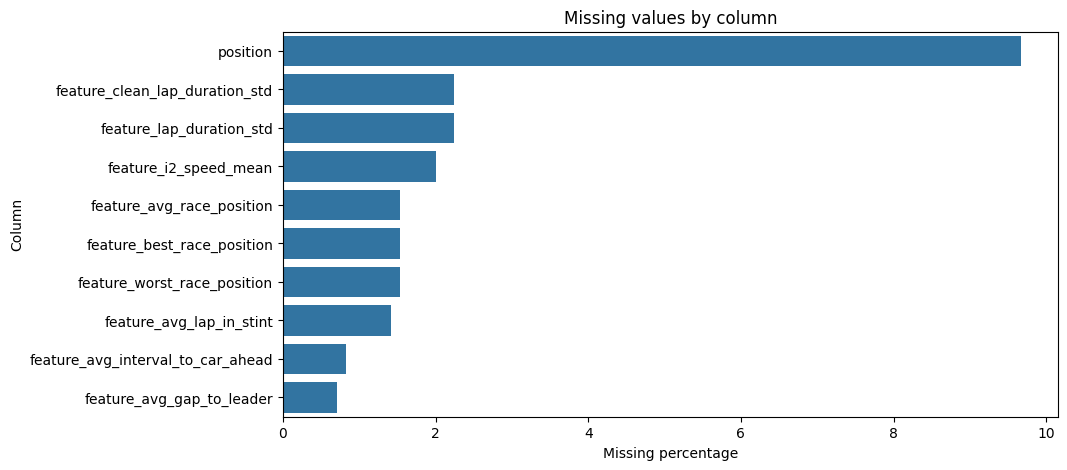

In [16]:
plt.figure(figsize=(10, 5))
missing_nonzero = missing[missing["missing_count"] > 0]
sns.barplot(
    data=missing_nonzero.reset_index(),
    y="index",
    x="missing_pct"
)
plt.xlabel("Missing percentage")
plt.ylabel("Column")
plt.title("Missing values by column")
plt.show()


### Analyze Target 

In [ ]:
df["position"].describe()
df["position"].value_counts(dropna=False).sort_index()

position
1.0     48
2.0     47
3.0     46
4.0     47
5.0     47
6.0     40
7.0     47
8.0     42
9.0     44
10.0    42
11.0    41
12.0    42
13.0    39
14.0    44
15.0    40
16.0    37
17.0    29
18.0    23
19.0    16
20.0     5
NaN     82
Name: count, dtype: int64

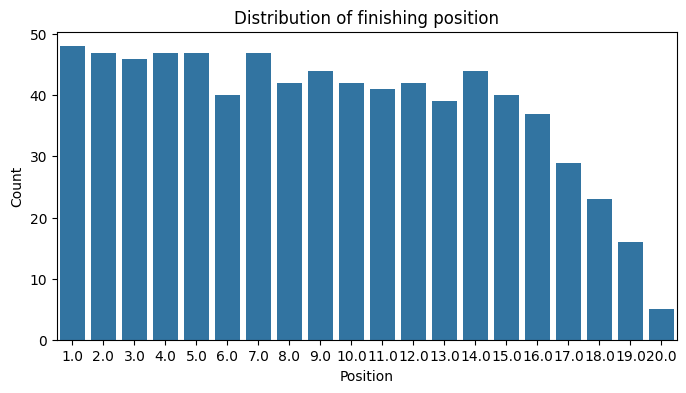

In [18]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="position", order=sorted(df["position"].dropna().unique()))
plt.title("Distribution of finishing position")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()


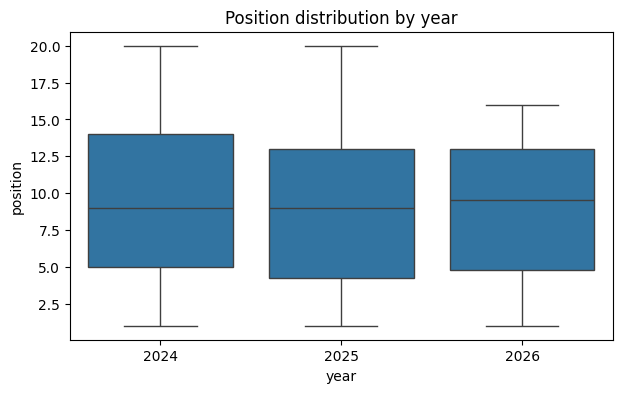

In [19]:
pd.crosstab(df["year"], df["position"].isna(), margins=True)

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="year", y="position")
plt.title("Position distribution by year")
plt.show()


### Split Feature in Groups

In [57]:
lap_cols = [c for c in df.columns if "lap" in c or "sector" in c]
speed_cols = [c for c in df.columns if "speed" in c]
pit_cols = [c for c in df.columns if "pit" in c]
tyre_cols = [c for c in df.columns if "tyre" in c or "compound" in c]
weather_cols = [c for c in df.columns if any(k in c for k in ["temperature", "humidity", "rain", "wind"])]
race_cols = [c for c in df.columns if "race_position" in c or "gap" in c or "interval" in c or "leader" in c]
telemetry_cols = [c for c in df.columns if any(k in c for k in ["throttle", "rpm", "ngear"])]

In [22]:
df[lap_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
total_laps_real,848.0,55.583726,14.978696,1.000000,51.000000,57.000000,66.000000,78.000000
used_laps_80,848.0,44.017689,11.925424,1.000000,40.000000,45.000000,52.000000,62.000000
max_lap_number,848.0,56.030660,14.566106,1.000000,52.000000,57.000000,66.000000,78.000000
feature_lap_count,848.0,44.017689,11.925424,1.000000,40.000000,45.000000,52.000000,62.000000
feature_lap_duration_mean,848.0,94.825932,14.897687,70.849000,83.760786,94.408467,101.519986,274.015600
feature_lap_duration_median,848.0,90.719754,10.696351,69.910000,82.454500,90.245000,98.609250,166.056000
feature_lap_duration_std,829.0,14.352618,38.185005,0.451871,3.701988,7.032504,13.141430,501.786461
feature_lap_duration_min,848.0,88.431281,10.586688,68.283000,80.308000,87.989000,96.536500,166.056000
feature_sector_1_mean,848.0,29.566973,6.045363,17.654000,26.838936,29.542381,33.057554,95.471000
feature_sector_2_mean,848.0,35.101437,7.500054,18.041413,30.114750,33.134413,40.980017,69.910000


In [23]:
df[speed_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
feature_i1_speed_mean,848.0,254.233101,41.372751,165.833333,214.185000,269.148718,286.058036,329.714286
feature_i2_speed_mean,831.0,249.273971,41.510832,71.000000,219.431707,256.200000,279.696429,331.000000
feature_st_speed_mean,848.0,298.017634,17.891370,94.000000,289.174107,299.364610,309.489583,339.901786
feature_st_speed_max,848.0,321.030660,20.296480,94.000000,309.000000,325.000000,334.000000,364.000000
feature_avg_wind_speed,848.0,1.803164,0.780363,0.593333,1.194315,1.662679,2.038799,4.658929
speed_max,848.0,332.896525,15.090145,232.000000,325.000000,333.000000,342.000000,369.000000
speed_mean,848.0,195.652268,25.936212,20.653761,181.210958,195.755783,212.992972,248.757780
speed_std,848.0,72.250038,7.871395,51.157422,66.377101,71.366480,76.453272,124.865022
speed_median,848.0,197.515067,34.033369,0.000000,174.292852,200.575404,222.000000,265.000000


In [24]:
df[pit_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
feature_total_pit_stops,848.0,1.560142,0.849288,0.0,1.000000,1.000000,2.000000,5.000000
feature_total_pit_duration,848.0,110.074662,373.251441,0.0,22.840000,35.300000,48.728500,2435.800000
feature_avg_pit_duration,848.0,2.506263,9.240066,0.0,0.531432,0.771350,1.124256,160.680000
feature_pit_lap_rate,848.0,0.035874,0.024203,0.0,0.022727,0.035088,0.044444,0.285714


In [25]:
df[tyre_cols].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
feature_most_used_compound,848,5,HARD,433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_avg_tyre_age,848.0,NaN,NaN,NaN,0.515004,1.750672,0.0,0.0,0.0,0.338889,23.0
feature_max_tyre_age,848.0,NaN,NaN,NaN,1.262972,4.041455,0.0,0.0,0.0,1.0,53.0
feature_compound_hard_laps,848.0,NaN,NaN,NaN,20.303066,14.932161,0.0,6.0,22.0,32.0,62.0
feature_compound_intermediate_laps,848.0,NaN,NaN,NaN,2.362028,8.842573,0.0,0.0,0.0,0.0,46.0
feature_compound_medium_laps,848.0,NaN,NaN,NaN,17.745283,12.687181,0.0,8.0,17.0,27.0,62.0
feature_compound_soft_laps,848.0,NaN,NaN,NaN,3.492925,7.690283,0.0,0.0,0.0,0.0,44.0
feature_compound_unknown_laps,848.0,NaN,NaN,NaN,0.09434,0.980599,0.0,0.0,0.0,0.0,17.0
feature_compound_wet_laps,848.0,NaN,NaN,NaN,0.020047,0.430067,0.0,0.0,0.0,0.0,11.0


In [26]:
df[weather_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
feature_avg_air_temperature,848.0,23.341322,4.856791,14.404762,18.761667,24.030000,26.995238,33.733333
feature_avg_track_temperature,848.0,34.998345,9.613230,17.355000,27.572807,36.044231,43.791250,52.150000
feature_avg_humidity,848.0,53.188996,15.691128,18.000000,43.434783,54.665899,63.370192,80.542857
feature_rain_rate,848.0,0.027226,0.095101,0.000000,0.000000,0.000000,0.000000,0.525000
feature_avg_wind_speed,848.0,1.803164,0.780363,0.593333,1.194315,1.662679,2.038799,4.658929


### Outlier

In [32]:
num_cols = df.select_dtypes(include="number").columns.difference(id_cols)

outlier_summary = df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
outlier_summary[["min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"]].head()

,min,1%,5%,25%,50%,75%,95%,99%,max
feature_avg_air_temperature,14.404762,14.414286,15.663415,18.761667,24.030000,26.995238,30.689218,32.902381,33.733333
feature_avg_gap_to_leader,0.000000,0.001740,1.669717,14.065465,30.456411,39.828304,50.968649,59.193027,87.355556
feature_avg_humidity,18.000000,18.886364,22.857143,43.434783,54.665899,63.370192,77.261905,80.428571,80.542857
feature_avg_interval_to_car_ahead,0.000000,0.001725,0.517300,1.851275,2.811523,4.301186,9.644846,20.882698,78.939571
feature_avg_lap_in_stint,1.000000,2.175000,6.978571,9.826714,11.590909,14.250000,19.525000,30.500000,31.500000


In [37]:
q1 = df[num_cols].quantile(0.25)
q3 = df[num_cols].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)

outlier_features = pd.DataFrame({
    "outlier_count": outlier_mask.sum(),
    "outlier_rate": outlier_mask.mean() * 100,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound
}).sort_values("outlier_rate", ascending=False)

outlier_features.head(20)



,outlier_count,outlier_rate,lower_bound,upper_bound
feature_compound_soft_laps,200,23.584906,0.000000,0.000000
throttle_max,187,22.051887,100.000000,100.000000
feature_avg_tyre_age,137,16.155660,-0.508333,0.847222
feature_max_tyre_age,131,15.448113,-1.500000,2.500000
feature_rain_rate,83,9.787736,0.000000,0.000000
feature_compound_intermediate_laps,82,9.669811,0.000000,0.000000
feature_avg_interval_to_car_ahead,64,7.547170,-1.823592,7.976053
feature_avg_pit_duration,58,6.839623,-0.357804,2.013491
feature_total_pit_duration,55,6.485849,-15.992750,87.561250
feature_clean_lap_count,53,6.250000,23.000000,63.000000


In [44]:
heavy_outlier_cols = (
    outlier_features
    .query("outlier_count > 0")
    .head(10)
    .index
    .tolist()
)

heavy_outlier_cols

['feature_compound_soft_laps',
 'throttle_max',
 'feature_avg_tyre_age',
 'feature_max_tyre_age',
 'feature_rain_rate',
 'feature_compound_intermediate_laps',
 'feature_avg_interval_to_car_ahead',
 'feature_avg_pit_duration',
 'feature_total_pit_duration',
 'feature_clean_lap_count']

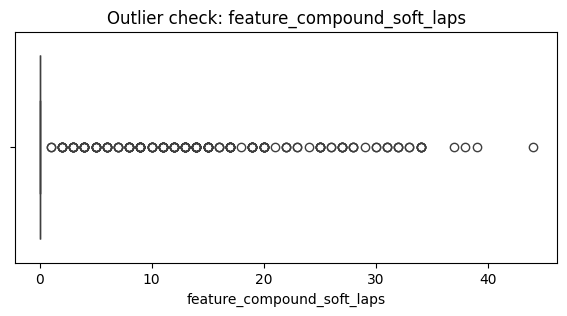

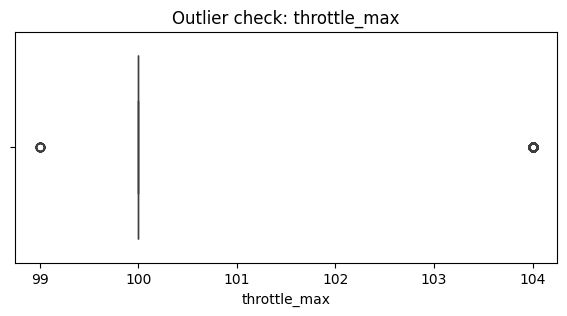

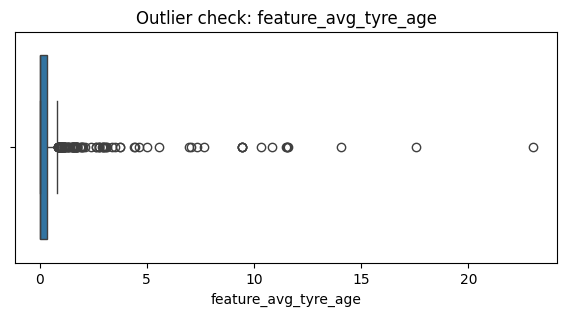

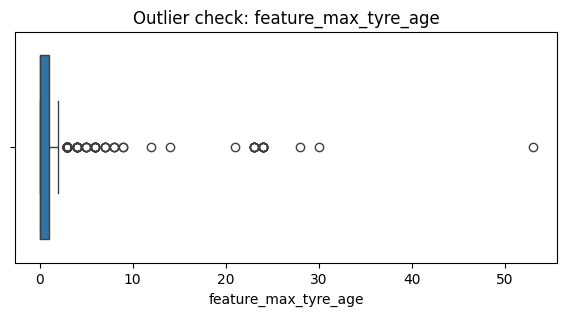

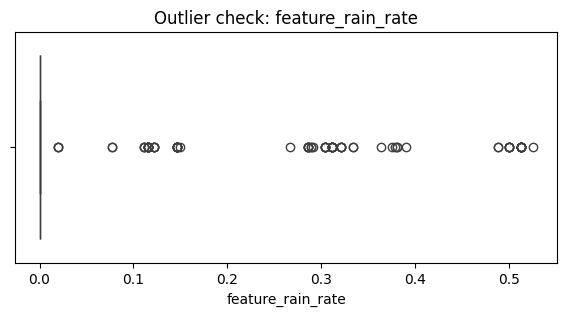

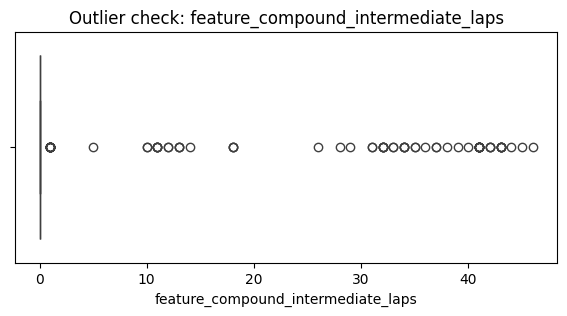

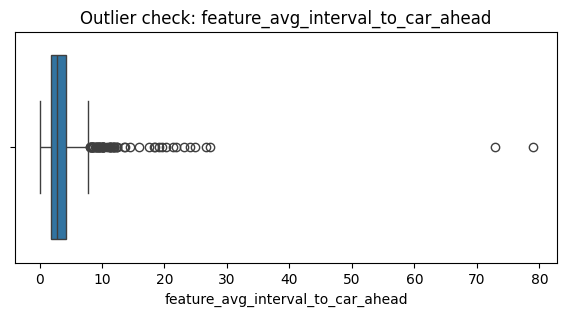

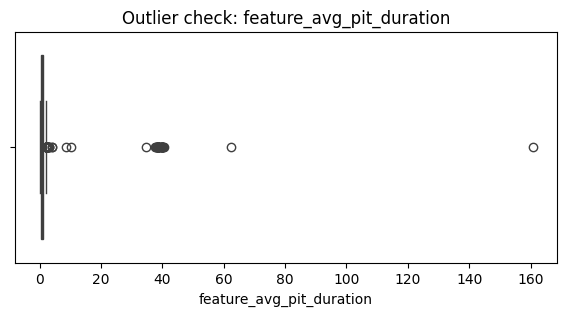

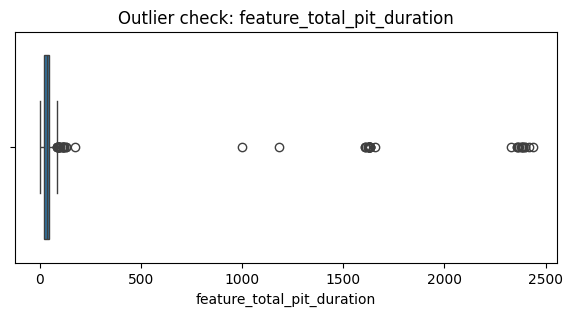

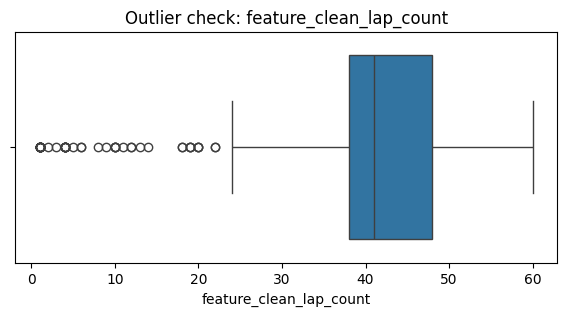

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in heavy_outlier_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Outlier check: {col}")
    plt.show()


In [40]:
check_cols = [
    "year", "meeting_key", "session_key", "driver_number", "position",
    "total_laps_real", "used_laps_80", "max_lap_number",
    "feature_lap_count"
]

col = "feature_lap_duration_mean"

outlier_rows = df.loc[outlier_mask[col], check_cols + [col]].sort_values(
    col,
    ascending=False
)

outlier_rows.head(10)


,year,meeting_key,session_key,driver_number,position,total_laps_real,used_laps_80,max_lap_number,feature_lap_count,feature_lap_duration_mean
63,2024,1232,9496,24,NaN,13,10,13,10,274.015600
793,2025,1258,10022,22,NaN,2,1,2,1,166.056000
822,2026,1279,11234,14,NaN,21,16,21,16,153.689062
55,2024,1232,9496,10,16.0,52,41,52,41,142.583268
65,2024,1232,9496,31,15.0,52,41,52,41,142.316415
64,2024,1232,9496,27,11.0,52,41,52,41,141.738244
59,2024,1232,9496,18,12.0,52,41,52,41,141.687829
69,2024,1232,9496,77,14.0,52,41,52,41,141.588341
60,2024,1232,9496,20,13.0,52,41,52,41,141.574317
66,2024,1232,9496,44,9.0,53,42,53,42,139.716690


### Categorical: Tyre compound

In [45]:
df["feature_most_used_compound"].value_counts(dropna=False)

feature_most_used_compound
HARD            433
MEDIUM          316
INTERMEDIATE     49
SOFT             38
Unknown          12
Name: count, dtype: int64

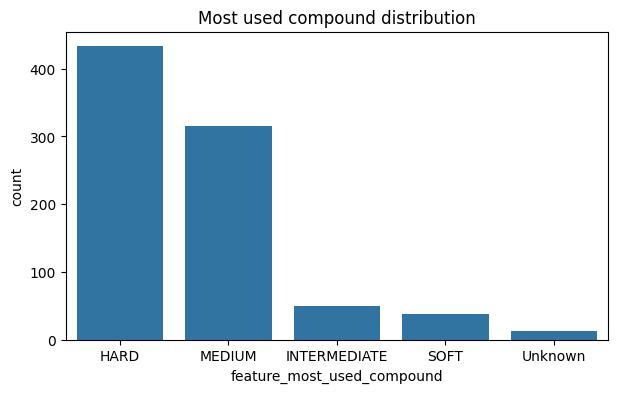

In [46]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x="feature_most_used_compound",
    order=df["feature_most_used_compound"].value_counts().index
)
plt.title("Most used compound distribution")
plt.show()


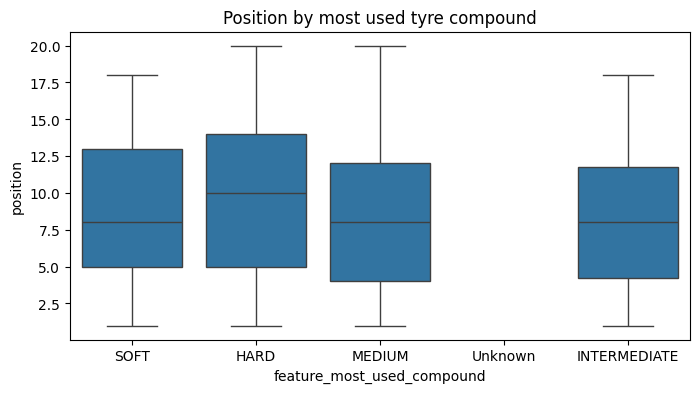

In [47]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="feature_most_used_compound", y="position")
plt.title("Position by most used tyre compound")
plt.show()


### Correlation with Target

In [48]:
feature_cols = df.select_dtypes(include="number").columns.drop(
    ["position", "session_key", "meeting_key", "driver_number"], 
    errors="ignore"
)

corr_with_target = (
    df[feature_cols.tolist() + ["position"]]
    .corr(numeric_only=True)["position"]
    .drop("position")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_with_target.head(20)


feature_avg_race_position             0.890405
feature_worst_race_position           0.830686
feature_best_race_position            0.816406
feature_avg_gap_to_leader             0.799881
speed_max                             0.130711
throttle_std                          0.121025
feature_compound_medium_laps         -0.119691
feature_avg_interval_to_car_ahead     0.115709
rpm_median                           -0.115416
rpm_mean                             -0.094353
feature_compound_hard_laps            0.089388
feature_clean_lap_duration_std       -0.080982
feature_clean_lap_rate               -0.065865
feature_compound_intermediate_laps   -0.061281
feature_lap_duration_median           0.059199
feature_clean_lap_duration_median     0.058195
feature_pit_lap_rate                  0.057443
feature_lap_duration_min              0.056671
feature_clean_lap_duration_min        0.056521
feature_compound_soft_laps            0.055364
Name: position, dtype: float64

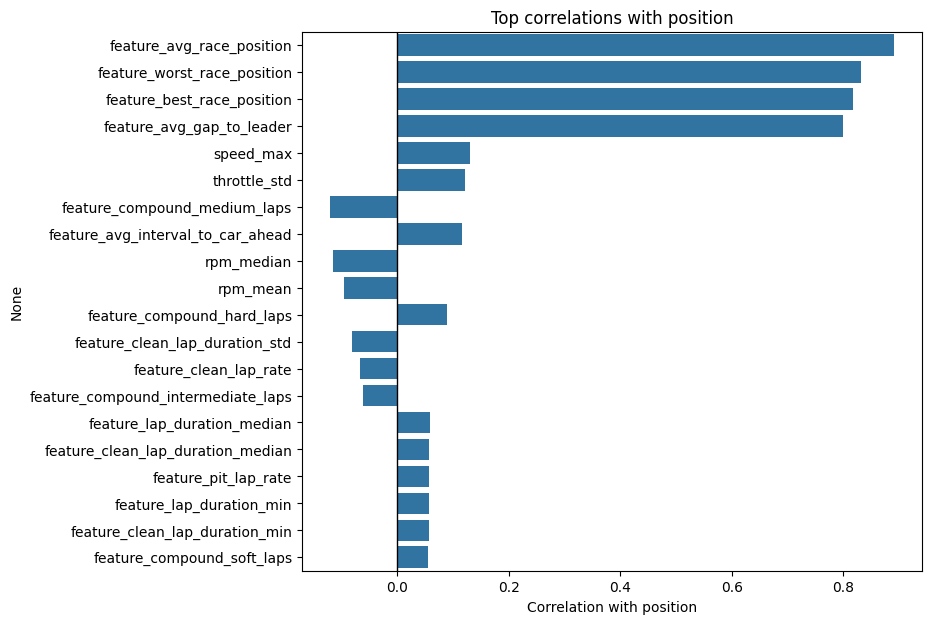

In [49]:
top_corr = corr_with_target.head(20)

plt.figure(figsize=(8, 7))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top correlations with position")
plt.xlabel("Correlation with position")
plt.show()


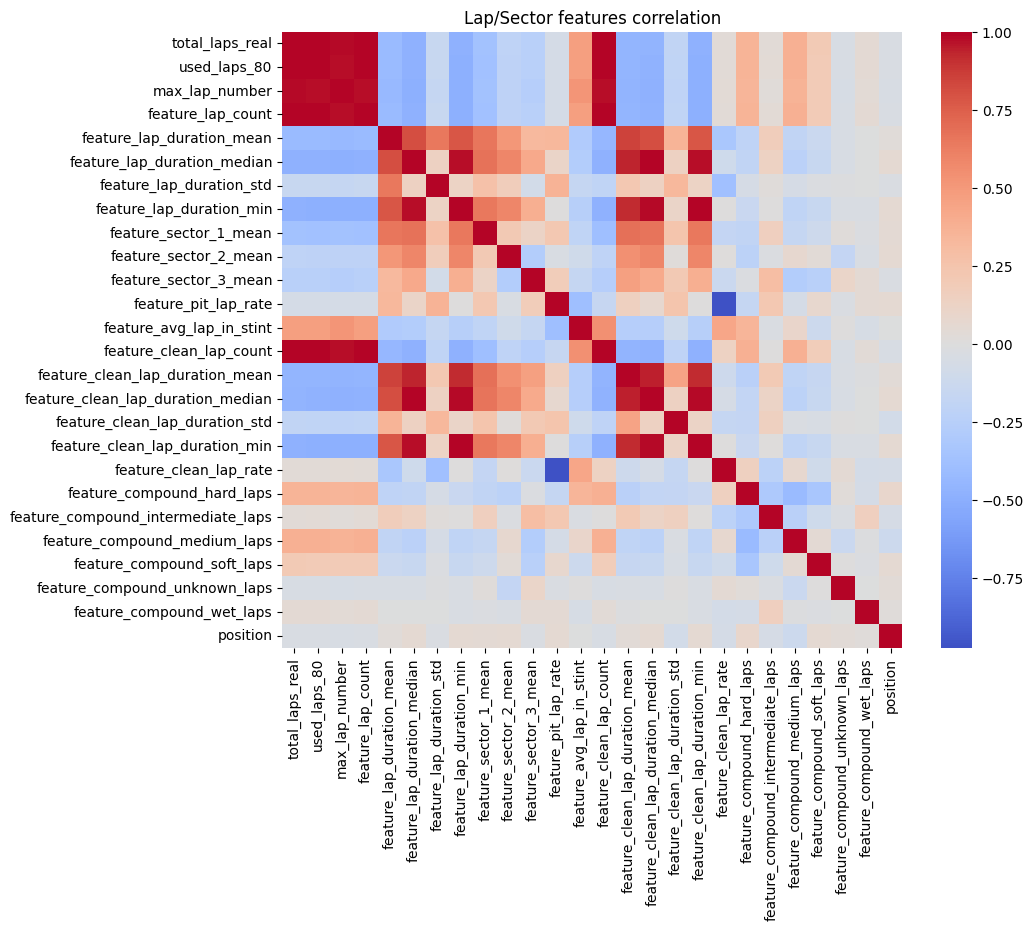

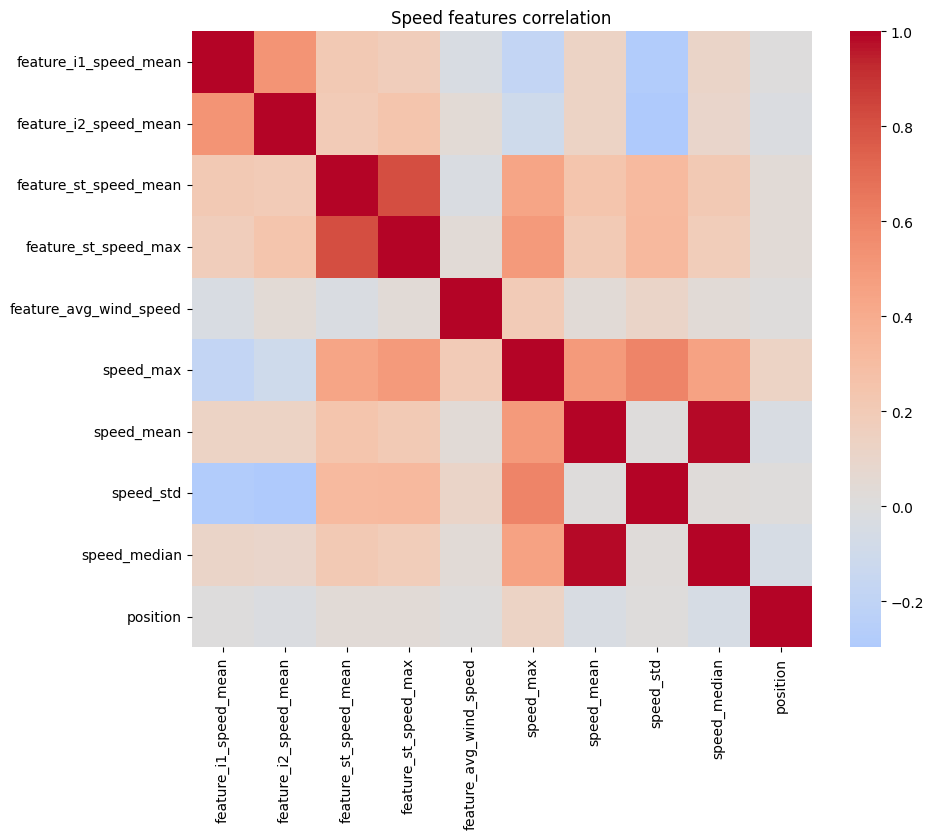

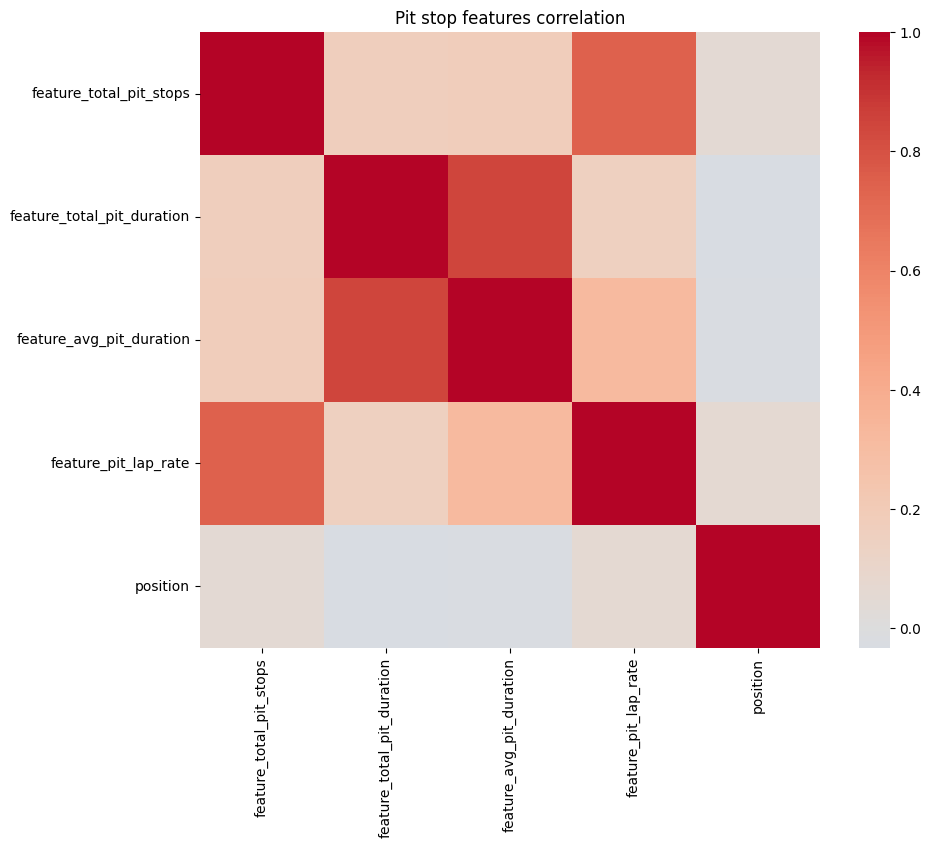

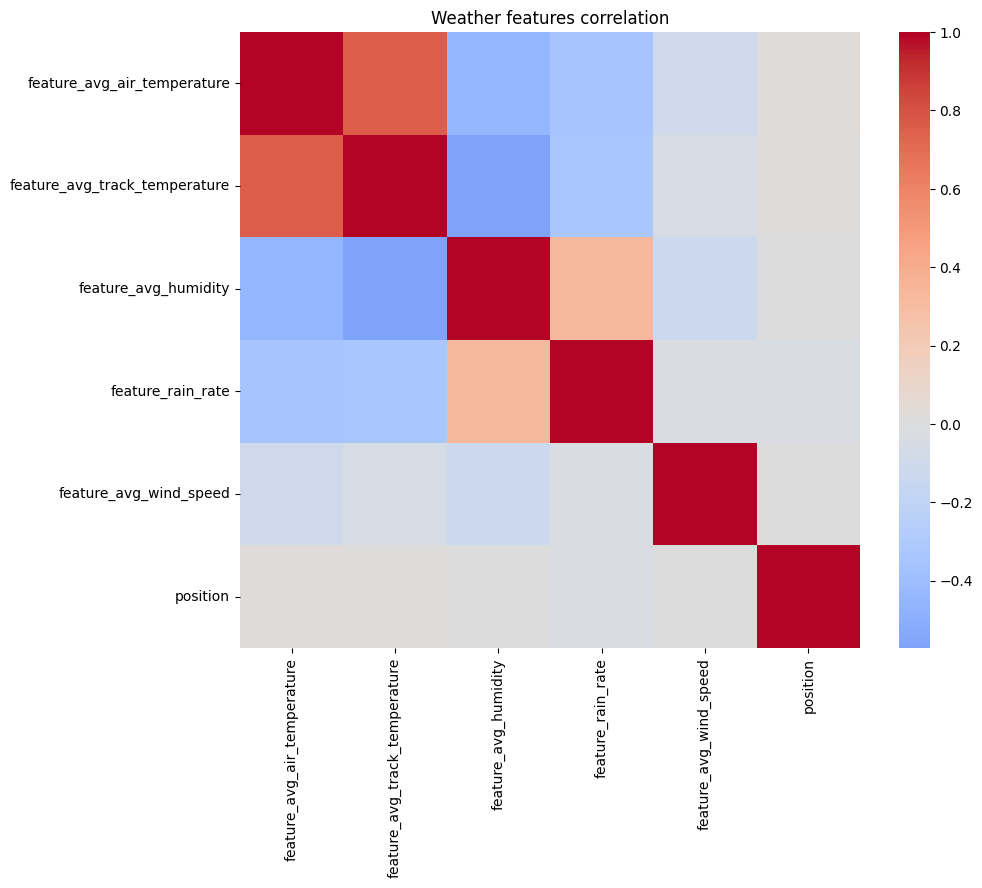

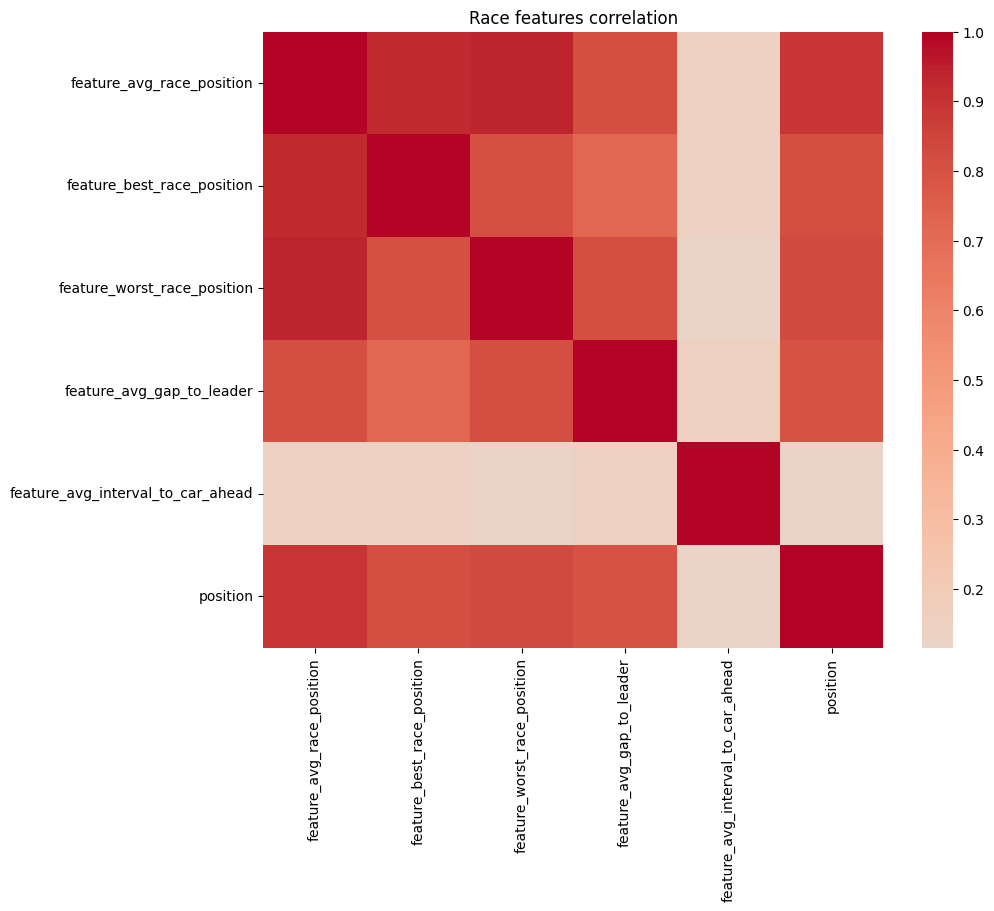

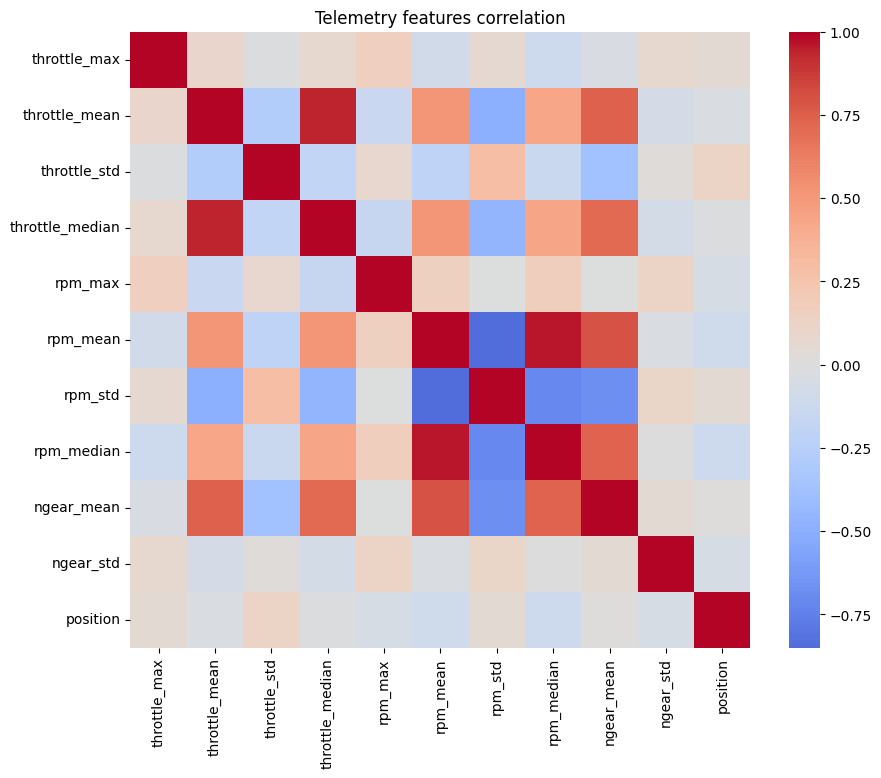

In [58]:
def plot_corr_heatmap(cols, title):
    corr = df[cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
    plt.title(title)
    plt.show()

plot_corr_heatmap(lap_cols + ["position"], "Lap/Sector features correlation")
plot_corr_heatmap(speed_cols + ["position"], "Speed features correlation")
plot_corr_heatmap(pit_cols + ["position"], "Pit stop features correlation")
plot_corr_heatmap(weather_cols + ["position"], "Weather features correlation")
plot_corr_heatmap(race_cols + ["position"], "Race features correlation")
plot_corr_heatmap(telemetry_cols + ["position"], "Telemetry features correlation")

### Relationship between Feature and Position

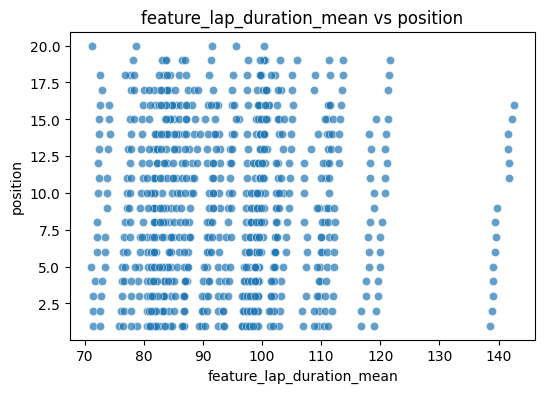

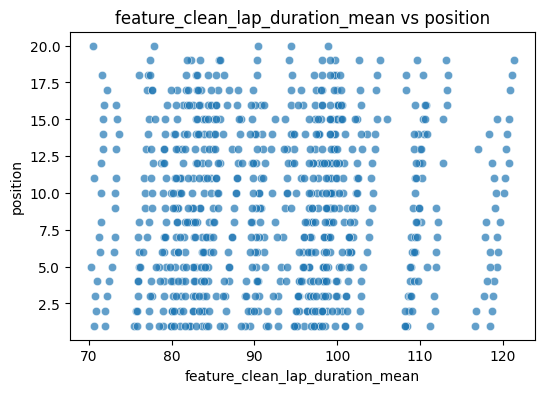

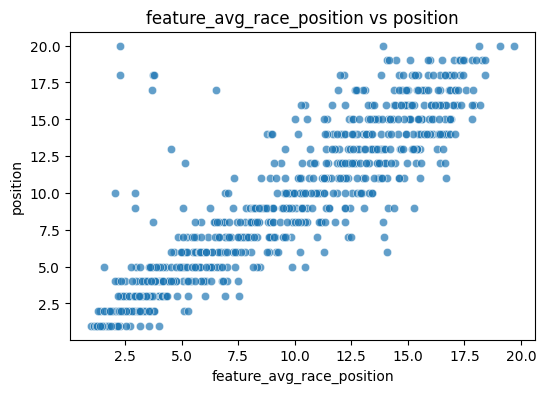

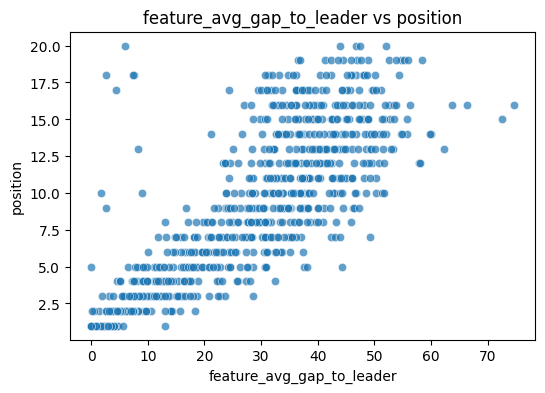

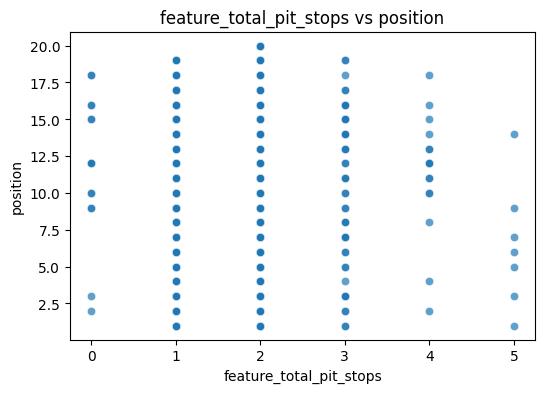

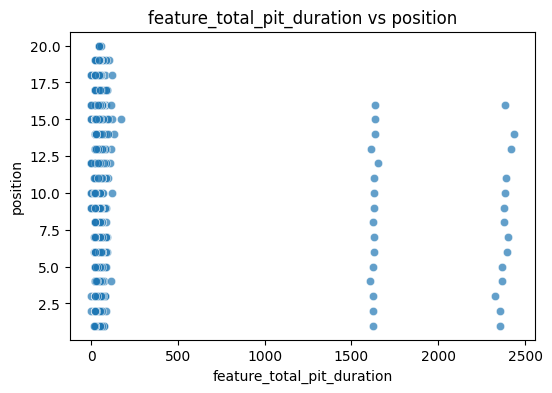

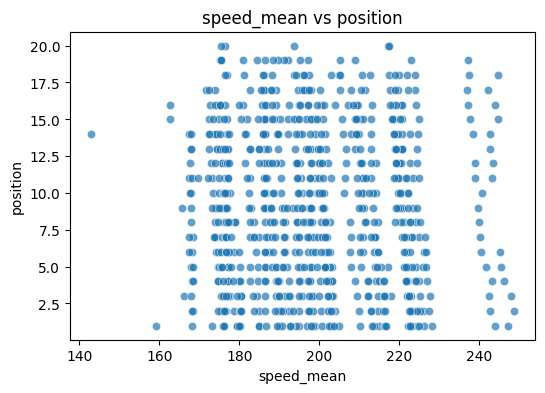

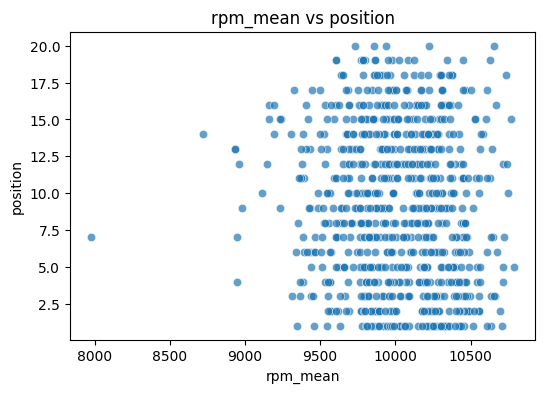

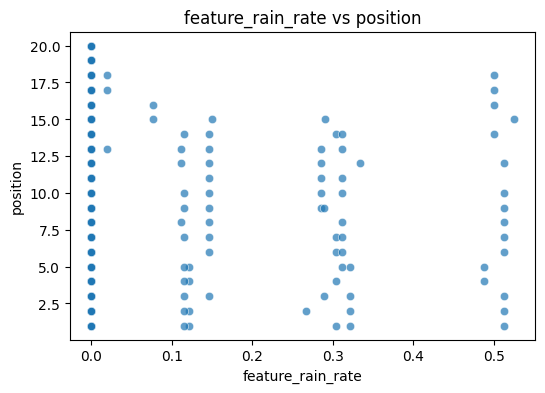

In [53]:
important_features = [
    "feature_lap_duration_mean",
    "feature_clean_lap_duration_mean",
    "feature_avg_race_position",
    "feature_avg_gap_to_leader",
    "feature_total_pit_stops",
    "feature_total_pit_duration",
    "speed_mean",
    "rpm_mean",
    "feature_rain_rate"
]

for col in important_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y="position", alpha=0.7)
    plt.title(f"{col} vs position")
    plt.show()


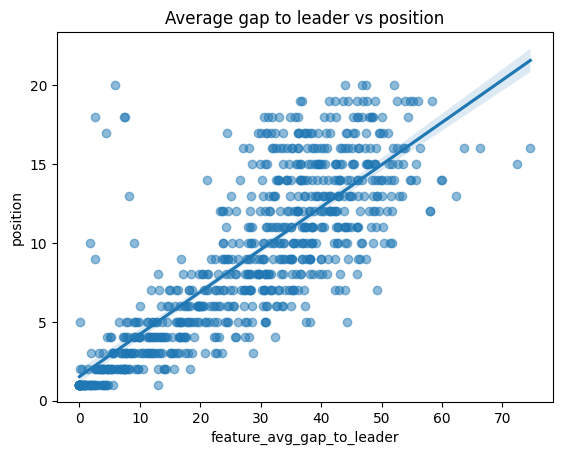

In [54]:
sns.regplot(
    data=df.dropna(subset=["position"]),
    x="feature_avg_gap_to_leader",
    y="position",
    scatter_kws={"alpha": 0.5}
)
plt.title("Average gap to leader vs position")
plt.show()


### EDA with Race/Session

In [55]:
session_summary = df.groupby(["year", "meeting_key", "session_key"]).agg(
    n_drivers=("driver_number", "count"),
    avg_laps=("feature_lap_count", "mean"),
    avg_position=("position", "mean"),
    missing_position=("position", lambda s: s.isna().sum()),
    rain_rate=("feature_rain_rate", "mean"),
    avg_track_temp=("feature_avg_track_temperature", "mean")
).reset_index()

session_summary.describe().T


,count,mean,std,min,25%,50%,75%,max
year,49.0,2024.571429,0.577350,2024.000000,2024.000000,2025.00000,2025.000000,2026.000000
meeting_key,49.0,1254.163265,15.222444,1229.000000,1241.000000,1255.00000,1267.000000,1280.000000
session_key,49.0,9811.795918,353.040719,9472.000000,9574.000000,9839.00000,9947.000000,11245.000000
n_drivers,49.0,17.306122,1.294284,14.000000,17.000000,17.00000,18.000000,20.000000
avg_laps,49.0,43.969361,7.059364,23.875000,39.789474,41.85000,49.058824,56.444444
avg_position,49.0,9.084090,0.754943,7.666667,8.500000,9.00000,9.722222,10.411765
missing_position,49.0,1.673469,1.248128,0.000000,1.000000,2.00000,2.000000,5.000000
rain_rate,49.0,0.027993,0.095010,0.000000,0.000000,0.00000,0.000000,0.496688
avg_track_temp,49.0,34.937104,9.700579,17.401728,27.574262,36.13334,43.379332,50.661594


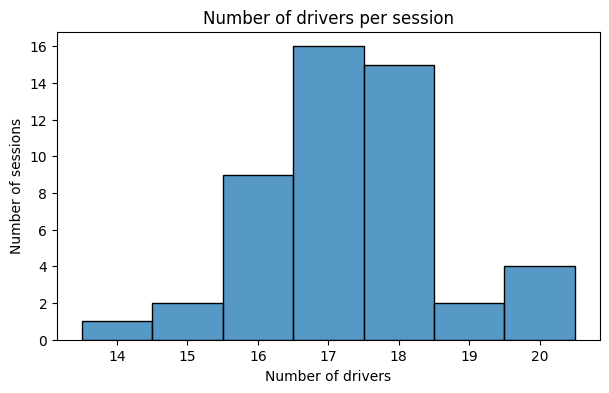

In [64]:
plt.figure(figsize=(7, 4))
sns.histplot(session_summary["n_drivers"], discrete=True)
plt.title("Number of drivers per session")
plt.xlabel("Number of drivers")
plt.ylabel("Number of sessions")
plt.show()


In [62]:
list(df["driver_number"].unique())

[np.int64(1),
 np.int64(4),
 np.int64(10),
 np.int64(11),
 np.int64(14),
 np.int64(16),
 np.int64(18),
 np.int64(20),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(27),
 np.int64(31),
 np.int64(44),
 np.int64(55),
 np.int64(63),
 np.int64(77),
 np.int64(81),
 np.int64(43),
 np.int64(30),
 np.int64(87)]

### Check Leakage

In [60]:
possible_leakage = [
    "feature_avg_race_position",
    "feature_best_race_position",
    "feature_worst_race_position",
    "feature_avg_gap_to_leader",
    "feature_avg_interval_to_car_ahead"
]
df[possible_leakage + ["position"]].corr(numeric_only=True)["position"].sort_values()


feature_avg_interval_to_car_ahead    0.115709
feature_avg_gap_to_leader            0.799881
feature_best_race_position           0.816406
feature_worst_race_position          0.830686
feature_avg_race_position            0.890405
position                             1.000000
Name: position, dtype: float64